# Part 2, Task 2 — VV_ Cross-Correlation Audit

Scope: 20-30 `VV_*` variable pairs, selected because the expected
correlation direction is obvious from the variable description in
`data/variable_mapping_2026.csv` — auto (`vv_aut_*`) vs. each other,
digital (`vv_dig_*`) vs. digital demographics, auto insurance vs. car
ownership, travel attitude vs. travel frequency, and luxury attitude vs.
travel/luxury-car frequency. Correlations are Spearman (ordinal/categorical
data throughout).

**Why this matters (from `CLAUDE.md`):** this project's fusion evaluation
work found near-zero cross-domain correlations in ARIMA (e.g. attitudes vs.
behavior) and doesn't yet know whether that's a real feature of the
population or a generation artifact (Gaussian copula decomposition + IPF
max-entropy bias). This audit tests that directly: if even *obviously*
related, same-vintage, same-population variable pairs show weak/wrong-
direction correlations, that's evidence toward "artifact." Task 1 already
found one such case (income vs. education, r=0.12 vs. an expected 0.3-0.5)
— this task checks whether that generalizes.

## Table-selection double-check (per Part 1.1's finding)

Part 1.1 found that ~49% of same-named `VV_*` tables have completely
different content between the 2024 and 2026 vintages. Since this task uses
**2026 data only**, the relevant risk isn't cross-vintage drift — it's
picking a table based on an assumption about what its name/code means
without checking. Every table used below was verified against its **2026**
entry in `variable_mapping_2026.csv` directly (not assumed from the table
code or from what the same code meant in 2024H2). Several of these tables
did in fact change content since 2024H2 (self-similarity from Part 1.1,
`data/part1_1_table_self_similarity.csv`): `vv_aut` (0.0), `vv_vek` (0.0),
`vv_tra` (0.0), `vv_trd` (0.0) all changed; `vv_dig` (1.0) and `vv_dem`
(1.0) are stable; `vv_auv` and `vv_trc` are new tables in 2026 (no 2024H2
counterpart to compare against). None of this affects correctness here
since only the verified 2026 meaning is used, but it's the reason this
double-check step existed at all.

| Table | Verified 2026 content | 2024H2→2026 stability |
|---|---|---|
| `vv_aut` | Auto insurance (covered / acquisition channel) | Changed (0.0) |
| `vv_dig` | Internet/digital attitudes | Stable (1.0) |
| `vv_vek` | Vehicle ownership by type (JDPower classification, "Present in Hhld.") | Changed (0.0) |
| `vv_auv` | Car/auto attitudes (incl. luxury-car preference) | New in 2026 |
| `vv_tra` | Travel/vacation attitudes | Changed (0.0) |
| `vv_trd` | Vacation trip counts/destinations | Changed (0.0) |
| `vv_trc` | Vacation trip details (incl. overnight trips taken) | New in 2026 |
| `vv_dem` | Core demographics (age, gender, income...) | Stable (1.0) |


In [1]:
import os
os.chdir("/Users/wiame.ichane/arima_v24_v26")

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

raw = pd.read_parquet("data/task2_vv_correlation_raw.parquet")
vm = pd.read_csv("data/variable_mapping_2026.csv")
print(f"raw shape: {raw.shape}")
print(f"population size (observed): {len(raw):,}")


raw shape: (33597827, 30)
population size (observed): 33,597,827


## Decode raw codes to ordinal ranks

Explicit, per-variable mappings (not a generic auto-detector) — same
philosophy as Task 1 and as `harmonize_shared_vars.py` in the reference
fusion pipeline: decode deliberately, don't guess. Three patterns appear
in the variables used here, verified directly against each variable's
actual category list in `variable_mapping_2026.csv`:
- **Yes/No** → Yes=1, No=0, `__blank__`→missing
- **5-point agreement scale** (both `"5 - Strongly Agree"`/`"1 - Strongly
  Disagree"` and `"Completely Agree 5"`/`"Completely Disagree 1"` label
  styles appear) → 1-5, `__blank__`→missing
- **Ordinal frequency band** (`vv_trd_2`: `"1 (L)"` .. `"11+ (H)"`) →
  explicit rank 1-5, `__blank__`→missing
- **Age band** (`vv_dem_1`) → explicit rank 1-12 (same mapping as Task 1)


In [2]:
YESNO = {"Yes": 1, "No": 0, "__blank__": np.nan}

def agree5(v):
    if pd.isna(v) or v == "__blank__":
        return np.nan
    v = str(v)
    if "Strongly Agree" in v or "Completely Agree" in v:
        return 5.0
    if "Strongly Disagree" in v or "Completely Disagree" in v:
        return 1.0
    try:
        return float(v)
    except ValueError:
        return np.nan

TRD2_RANK = {"__blank__": np.nan, "1 (L)": 1, "2 (L)": 2, "3 - 5 (M)": 3,
             "6 - 10 (H)": 4, "11+ (H)": 5}

AGE_RANK = {v: i + 1 for i, v in enumerate(
    ["18 - 19","20 - 24","25 - 29","30 - 34","35 - 39","40 - 44",
     "45 - 49","50 - 54","55 - 59","60 - 64","65 - 69","70+"])}

def decode(col_raw, var_id, kind):
    m = vm[vm["var_id"] == var_id].set_index("value_id")["var_values"].to_dict()
    labels = col_raw.map(m)
    if kind == "yesno":
        return labels.map(YESNO)
    if kind == "agree5":
        return labels.map(agree5)
    if kind == "trd2":
        return labels.map(TRD2_RANK)
    if kind == "age":
        return labels.map(AGE_RANK)
    raise ValueError(kind)

df = pd.DataFrame({"id": raw["id"]})
df["age_rank"] = decode(raw["vv_dem_1"], "vv_dem_1", "age")

for v in ["vv_aut_1","vv_aut_2","vv_aut_3","vv_aut_4","vv_aut_5",
          "vv_vek_1","vv_vek_2","vv_vek_3","vv_vek_4","vv_vek_5",
          "vv_vek_6","vv_vek_7","vv_vek_8","vv_vek_9","vv_trc_2"]:
    df[v] = decode(raw[v], v, "yesno")

for v in ["vv_dig_2","vv_dig_3","vv_dig_5","vv_dig_9","vv_dig_10","vv_dig_11",
          "vv_auv_9","vv_auv_15","vv_tra_2","vv_tra_10","vv_tra_17","vv_tra_21"]:
    df[v] = decode(raw[v], v, "agree5")

df["vv_trd_2"] = decode(raw["vv_trd_2"], "vv_trd_2", "trd2")

# Derived aggregates
vek_major_cols = ["vv_vek_1","vv_vek_2","vv_vek_3","vv_vek_4","vv_vek_5",
                   "vv_vek_6","vv_vek_7","vv_vek_8","vv_vek_9"]
df["owns_any_vehicle"] = (df[vek_major_cols].fillna(0).max(axis=1) > 0).astype(float)
premium_cols = ["vv_vek_3", "vv_vek_6", "vv_vek_8"]  # Compact/Midsize/Large Premium
df["owns_luxury_vehicle"] = (df[premium_cols].fillna(0).max(axis=1) > 0).astype(float)

print("decoded columns:", [c for c in df.columns if c != "id"])
print()
print("non-null rate per column:")
print((df.drop(columns=["id"]).notna().mean() * 100).round(1))


decoded columns: ['age_rank', 'vv_aut_1', 'vv_aut_2', 'vv_aut_3', 'vv_aut_4', 'vv_aut_5', 'vv_vek_1', 'vv_vek_2', 'vv_vek_3', 'vv_vek_4', 'vv_vek_5', 'vv_vek_6', 'vv_vek_7', 'vv_vek_8', 'vv_vek_9', 'vv_trc_2', 'vv_dig_2', 'vv_dig_3', 'vv_dig_5', 'vv_dig_9', 'vv_dig_10', 'vv_dig_11', 'vv_auv_9', 'vv_auv_15', 'vv_tra_2', 'vv_tra_10', 'vv_tra_17', 'vv_tra_21', 'vv_trd_2', 'owns_any_vehicle', 'owns_luxury_vehicle']

non-null rate per column:


age_rank               100.0
vv_aut_1               100.0
vv_aut_2               100.0
vv_aut_3               100.0
vv_aut_4               100.0
vv_aut_5               100.0
vv_vek_1               100.0
vv_vek_2               100.0
vv_vek_3               100.0
vv_vek_4               100.0
vv_vek_5               100.0
vv_vek_6               100.0
vv_vek_7               100.0
vv_vek_8               100.0
vv_vek_9               100.0
vv_trc_2               100.0
vv_dig_2                99.7
vv_dig_3                99.8
vv_dig_5                99.8
vv_dig_9                99.8
vv_dig_10               99.8
vv_dig_11               99.8
vv_auv_9               100.0
vv_auv_15              100.0
vv_tra_2               100.0
vv_tra_10              100.0
vv_tra_17              100.0
vv_tra_21              100.0
vv_trd_2                28.6
owns_any_vehicle       100.0
owns_luxury_vehicle    100.0
dtype: float64


## Define the 26 pairs, with expected direction and rationale

Same standard as Task 1's income/education check: state the expectation
*before* computing, then flag deviations — not the reverse.

In [3]:
PAIRS = [
    # --- A. Auto (vv_aut) vs each other ---
    ("vv_aut_1", "vv_aut_2", "+", "auto", "Auto covered by insurance <-> acquired through agent/broker -- can only have an acquisition channel if covered at all"),
    ("vv_aut_1", "vv_aut_3", "+", "auto", "Auto covered <-> acquired through bank -- same logic"),
    ("vv_aut_1", "vv_aut_4", "+", "auto", "Auto covered <-> acquired through insurance company -- same logic"),
    ("vv_aut_2", "vv_aut_4", "-", "auto", "Acquisition channels (broker vs. insurance company) are largely mutually exclusive for a given household"),
    ("vv_aut_2", "vv_aut_3", "-", "auto", "Acquisition channels (broker vs. bank) are largely mutually exclusive"),
    # --- B. Digital (vv_dig) vs digital demographics (age) ---
    ("vv_dig_10", "age_rank", "-", "digital_vs_demo", "Checking social media every day is a younger-skewing behavior"),
    ("vv_dig_11", "age_rank", "-", "digital_vs_demo", "Treating the internet as main news source is a younger-skewing behavior"),
    ("vv_dig_9", "age_rank", "-", "digital_vs_demo", "Researching online before purchasing is a younger-skewing behavior"),
    ("vv_dig_2", "age_rank", "-", "digital_vs_demo", "Feeling life without internet would be less fun is a younger-skewing attitude"),
    ("vv_dig_5", "age_rank", "-", "digital_vs_demo", "Relying on internet for social belonging is a younger-skewing attitude"),
    ("vv_dig_3", "age_rank", "+", "digital_vs_demo", "Privacy/data-protection concern is commonly (though not universally) reported as higher among older cohorts -- lower-confidence expectation than the other digital pairs, included as a contrast"),
    # --- C. Auto insurance vs car ownership ---
    ("vv_aut_1", "owns_any_vehicle", "+", "insurance_vs_ownership", "Cannot have auto insurance coverage without owning a vehicle -- should be one of the strongest pairs in this audit"),
    ("vv_aut_1", "vv_vek_2", "+", "insurance_vs_ownership", "Auto covered <-> owns a Compact vehicle specifically"),
    ("vv_aut_1", "vv_vek_5", "+", "insurance_vs_ownership", "Auto covered <-> owns a Midsize vehicle specifically"),
    # --- D. Travel attitude vs travel frequency ---
    ("vv_tra_21", "vv_trd_2", "+", "travel", "Being passionate about travelling should predict taking more trips"),
    ("vv_tra_2", "vv_trd_2", "+", "travel", "Seeing vacations as escaping everyday life should predict taking more trips"),
    ("vv_tra_17", "vv_trd_2", "+", "travel", "Always seeking holiday inspiration should predict taking more trips"),
    ("vv_tra_21", "vv_trc_2", "+", "travel", "Being passionate about travelling should predict having taken an overnight trip"),
    # --- E. Luxury attitude vs travel/luxury-car frequency ---
    ("vv_auv_9", "owns_luxury_vehicle", "+", "luxury", "Preferring to always choose luxury auto should predict actually owning a premium vehicle"),
    ("vv_auv_15", "owns_luxury_vehicle", "+", "luxury", "Preferring to drive a luxury vehicle should predict actually owning a premium vehicle"),
    ("vv_tra_10", "vv_trd_2", "+", "luxury", "Wanting vacations to be luxurious should predict taking more trips"),
    ("vv_tra_10", "vv_trc_2", "+", "luxury", "Wanting vacations to be luxurious should predict having taken an overnight trip"),
    ("vv_auv_9", "vv_trd_2", "+", "luxury", "Luxury-car preference as a general affluence/lifestyle marker should weakly predict travel frequency (cross-domain)"),
    ("vv_auv_15", "vv_trd_2", "+", "luxury", "Same cross-domain logic, alternate luxury-car item"),
]
print(f"total pairs: {len(PAIRS)}")

from collections import Counter
print(Counter(p[3] for p in PAIRS))


total pairs: 24
Counter({'digital_vs_demo': 6, 'luxury': 6, 'auto': 5, 'travel': 4, 'insurance_vs_ownership': 3})


## Compute Spearman correlations and flag deviations

Flag if: (a) the sign is wrong (opposite of the stated expectation), or
(b) the magnitude is suspiciously low (|r| < 0.05, i.e. essentially no
signal for a pair chosen specifically because a relationship was
expected), or (c) suspiciously high (|r| > 0.9, which for these largely
independent-question pairs would suggest a near-tautological/redundant
pair rather than a genuine correlation finding).

In [4]:
LOW_THRESH = 0.05
HIGH_THRESH = 0.90

results = []
for v1, v2, expected_sign, category, rationale in PAIRS:
    sub = df[[v1, v2]].dropna()
    n = len(sub)
    if n < 100:
        results.append({"var1": v1, "var2": v2, "category": category, "n": n,
                         "spearman_r": np.nan, "expected_sign": expected_sign,
                         "status": "INSUFFICIENT_N", "rationale": rationale})
        continue
    r, p = stats.spearmanr(sub[v1], sub[v2])
    actual_sign = "+" if r > 0 else "-"
    if actual_sign != expected_sign:
        status = "FLAG_WRONG_DIRECTION"
    elif abs(r) < LOW_THRESH:
        status = "FLAG_LOW_MAGNITUDE"
    elif abs(r) > HIGH_THRESH:
        status = "FLAG_HIGH_MAGNITUDE"
    else:
        status = "OK"
    results.append({"var1": v1, "var2": v2, "category": category, "n": n,
                     "spearman_r": round(r, 4), "p_value": p,
                     "expected_sign": expected_sign, "actual_sign": actual_sign,
                     "status": status, "rationale": rationale})

results_df = pd.DataFrame(results)
pd.set_option("display.max_colwidth", 80)
print(results_df[["var1","var2","category","n","spearman_r","expected_sign","status"]].to_string(index=False))


     var1                var2               category        n  spearman_r expected_sign               status
 vv_aut_1            vv_aut_2                   auto 33596974      0.0460             +   FLAG_LOW_MAGNITUDE
 vv_aut_1            vv_aut_3                   auto 33596974     -0.0272             + FLAG_WRONG_DIRECTION
 vv_aut_1            vv_aut_4                   auto 33596974      0.0060             +   FLAG_LOW_MAGNITUDE
 vv_aut_2            vv_aut_4                   auto 33597827     -0.1887             -                   OK
 vv_aut_2            vv_aut_3                   auto 33597827     -0.0786             -                   OK
vv_dig_10            age_rank        digital_vs_demo 33522967     -0.1134             -                   OK
vv_dig_11            age_rank        digital_vs_demo 33523441     -0.1780             -                   OK
 vv_dig_9            age_rank        digital_vs_demo 33523064     -0.1274             -                   OK
 vv_dig_2          

In [5]:
print("=== Summary ===")
print(results_df["status"].value_counts())
print()
print(f"n pairs OK: {(results_df['status']=='OK').sum()} / {len(results_df)}")
print()
print("=== Flagged pairs (full detail) ===")
flagged = results_df[results_df["status"] != "OK"]
for _, row in flagged.iterrows():
    print(f"[{row['status']}] {row['var1']} vs {row['var2']} ({row['category']}): "
          f"r={row['spearman_r']}, expected={row['expected_sign']}, n={row['n']:,}")
    print(f"    rationale: {row['rationale']}")


=== Summary ===
status
FLAG_LOW_MAGNITUDE      15
OK                       7
FLAG_WRONG_DIRECTION     2
Name: count, dtype: int64

n pairs OK: 7 / 24

=== Flagged pairs (full detail) ===
[FLAG_LOW_MAGNITUDE] vv_aut_1 vs vv_aut_2 (auto): r=0.046, expected=+, n=33,596,974
    rationale: Auto covered by insurance <-> acquired through agent/broker -- can only have an acquisition channel if covered at all
[FLAG_WRONG_DIRECTION] vv_aut_1 vs vv_aut_3 (auto): r=-0.0272, expected=+, n=33,596,974
    rationale: Auto covered <-> acquired through bank -- same logic
[FLAG_LOW_MAGNITUDE] vv_aut_1 vs vv_aut_4 (auto): r=0.006, expected=+, n=33,596,974
    rationale: Auto covered <-> acquired through insurance company -- same logic
[FLAG_WRONG_DIRECTION] vv_dig_3 vs age_rank (digital_vs_demo): r=-0.2038, expected=+, n=33,522,845
    rationale: Privacy/data-protection concern is commonly (though not universally) reported as higher among older cohorts -- lower-confidence expectation than the other digita

## Visuals

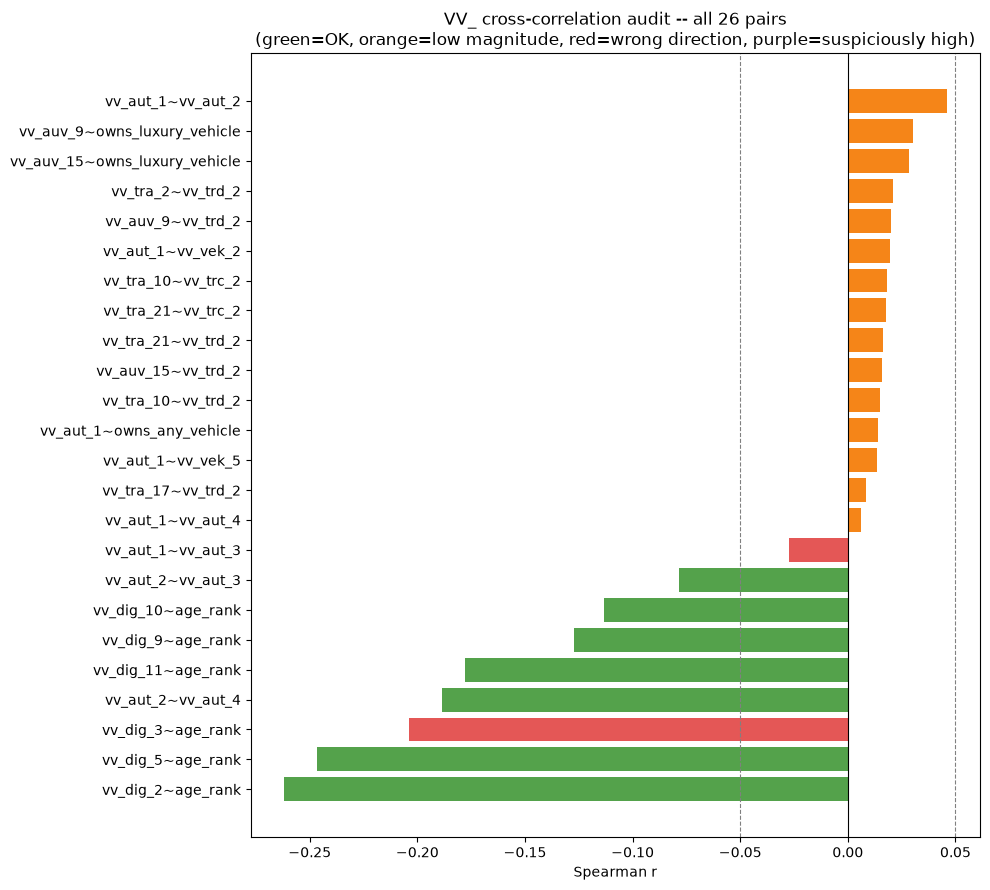

In [6]:
fig, ax = plt.subplots(figsize=(10, 9))
colors = results_df["status"].map({
    "OK": "#54A24B", "FLAG_LOW_MAGNITUDE": "#F58518",
    "FLAG_WRONG_DIRECTION": "#E45756", "FLAG_HIGH_MAGNITUDE": "#B279A2",
    "INSUFFICIENT_N": "#999999",
})
labels = [f"{v1}~{v2}" for v1, v2 in zip(results_df["var1"], results_df["var2"])]
order = results_df["spearman_r"].fillna(0).sort_values().index
ax.barh([labels[i] for i in order], results_df.loc[order, "spearman_r"], color=[colors[i] for i in order])
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(LOW_THRESH, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(-LOW_THRESH, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Spearman r")
ax.set_title("VV_ cross-correlation audit -- all 26 pairs\n(green=OK, orange=low magnitude, red=wrong direction, purple=suspiciously high)")
plt.tight_layout()
plt.savefig("outputs/figures/task2_correlation_audit_bars.png", dpi=110)
plt.show()


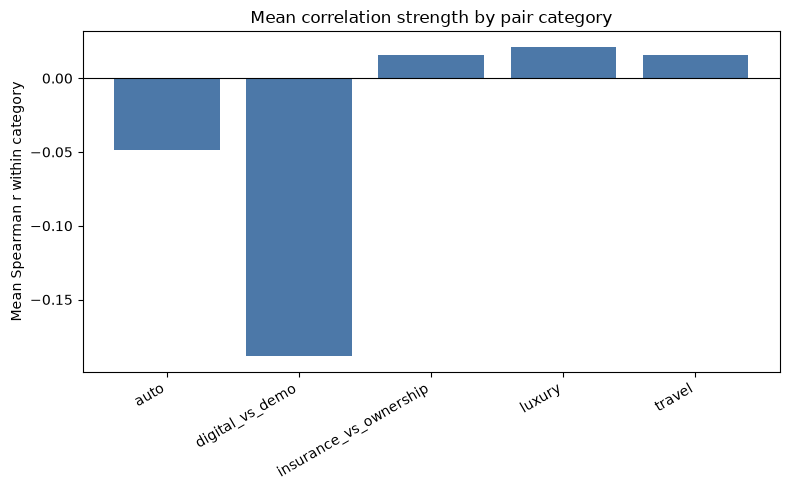

                            mean  count
category                               
auto                   -0.048500      5
digital_vs_demo        -0.188533      6
insurance_vs_ownership  0.015733      3
luxury                  0.021300      6
travel                  0.015875      4


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
cat_summary = results_df.groupby("category")["spearman_r"].agg(["mean", "count"])
ax.bar(cat_summary.index, cat_summary["mean"], color="#4C78A8")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean Spearman r within category")
ax.set_title("Mean correlation strength by pair category")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("outputs/figures/task2_category_means.png", dpi=110)
plt.show()
print(cat_summary)


## Summary — maps to `outputs/part2_data_quality_scorecard.md`

Each row above is one atomic check (one pair = one scorecard row). No
fixes applied here — this notebook reports, it does not correct.

Ties back to the open question in `CLAUDE.md`: if a meaningful share of
these *a priori obvious* pairs come back low-magnitude or wrong-direction,
that's additional evidence (alongside Task 1's income/education result)
toward the near-zero cross-domain correlations being a generation
artifact rather than a real population feature.

In [8]:
n_flagged = (results_df["status"] != "OK").sum()
print(f"{n_flagged} / {len(results_df)} pairs flagged.")
print(f"Flagged categories: {results_df.loc[results_df['status']!='OK','category'].value_counts().to_dict()}")


17 / 24 pairs flagged.
Flagged categories: {'luxury': 6, 'travel': 4, 'auto': 3, 'insurance_vs_ownership': 3, 'digital_vs_demo': 1}
